# Exoplanet Classification with Neural Networks

This notebook extends the classical models with PyTorch neural networks.

**Methodological rule:** validation data are used for architecture selection and early stopping. The test set is evaluated only after a model configuration has been selected.

In [1]:
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_score, recall_score, roc_auc_score, roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = Path('../data/exoplanet.csv')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError('Expected ../data/exoplanet.csv. See data/README.md.')

df = pd.read_csv(DATA_PATH)
features = ['pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'st_teff', 'st_rad', 'st_mass']
df_clean = df.dropna(subset=features + ['planet_class']).copy()

le = LabelEncoder()
X = df_clean[features].to_numpy(dtype=np.float32)
y = le.fit_transform(df_clean['planet_class'])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print('Classes:', list(le.classes_))
print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)

Classes: ['Gas Giant', 'Neptune-like', 'Super-Earth', 'Terrestrial']
Train: (3842, 7) Validation: (961, 7) Test: (1201, 7)


## 1. Baseline ANN and confusion analysis

The baseline uses one hidden layer and no class weighting. Training curves use **validation** accuracy, not test accuracy.

,epoch,train_loss,train_accuracy,validation_accuracy
15,16,0.971,0.602,0.592
16,17,0.966,0.603,0.594
17,18,0.962,0.608,0.595
18,19,0.959,0.607,0.598
19,20,0.955,0.610,0.596


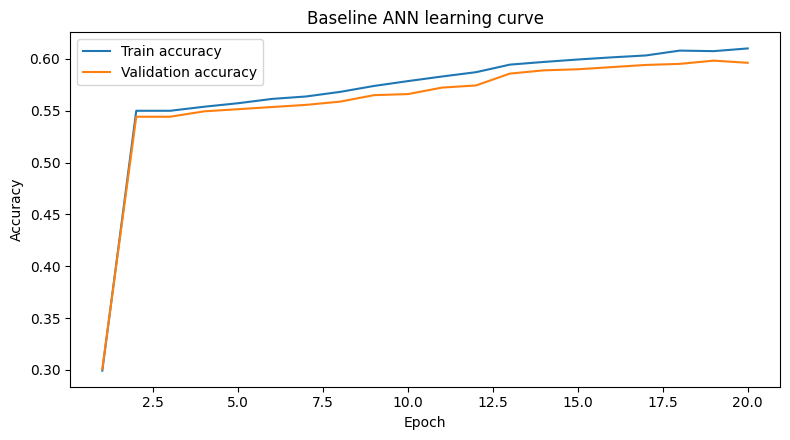

Most confused validation pair: ['Super-Earth', 'Terrestrial'] (147 cross-confusions)


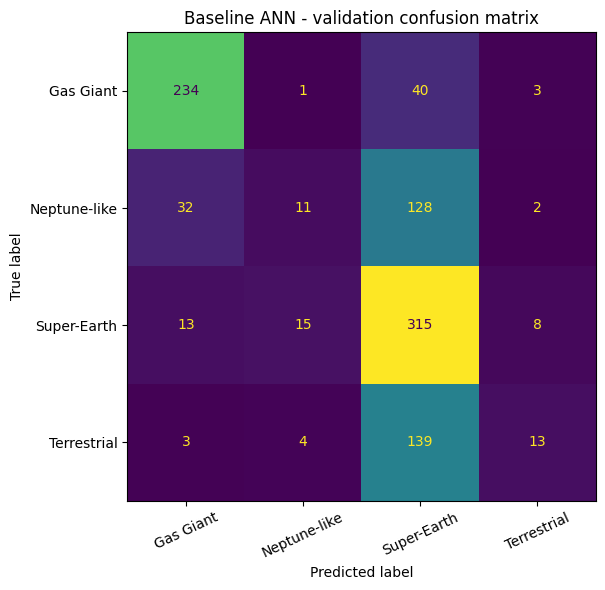

In [2]:
def make_loader(X_arr, y_arr, batch_size=64, shuffle=True, seed=SEED):
    ds = TensorDataset(torch.tensor(X_arr, dtype=torch.float32), torch.tensor(y_arr, dtype=torch.long))
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, generator=generator if shuffle else None)

train_loader = make_loader(X_train, y_train)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_dims:
            layers.extend([nn.Linear(prev, width), nn.ReLU()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = width
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def multiclass_metrics(model, X_t, y_true):
    model.eval()
    with torch.no_grad():
        pred = model(X_t).argmax(dim=1).cpu().numpy()
    return {
        'accuracy': accuracy_score(y_true, pred),
        'macro_f1': f1_score(y_true, pred, average='macro'),
        'pred': pred,
    }

baseline = MLP(len(features), [32], len(le.classes_))
optimizer = torch.optim.Adam(baseline.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history = []
for epoch in range(20):
    baseline.train()
    running_loss = 0.0
    seen = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = baseline(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)
        seen += len(xb)

    train_m = multiclass_metrics(baseline, X_train_t, y_train)
    val_m = multiclass_metrics(baseline, X_val_t, y_val)
    history.append({
        'epoch': epoch + 1,
        'train_loss': running_loss / seen,
        'train_accuracy': train_m['accuracy'],
        'validation_accuracy': val_m['accuracy'],
    })

history_df = pd.DataFrame(history)
display(history_df.tail().round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history_df['epoch'], history_df['train_accuracy'], label='Train accuracy')
ax.plot(history_df['epoch'], history_df['validation_accuracy'], label='Validation accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Baseline ANN learning curve')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'ann_baseline_learning_curve.png', dpi=160, bbox_inches='tight')
plt.show()

baseline_val = multiclass_metrics(baseline, X_val_t, y_val)
cm_val = confusion_matrix(y_val, baseline_val['pred'])

# Find the pair with the largest two-way confusion on validation data.
best_pair = None
for i in range(len(le.classes_)):
    for j in range(i + 1, len(le.classes_)):
        pair_errors = cm_val[i, j] + cm_val[j, i]
        if best_pair is None or pair_errors > best_pair[0]:
            best_pair = (pair_errors, i, j)

_, pair_i, pair_j = best_pair
confused_pair = [le.classes_[pair_i], le.classes_[pair_j]]
print('Most confused validation pair:', confused_pair, f'({best_pair[0]} cross-confusions)')

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_val, display_labels=le.classes_).plot(ax=ax, values_format='d', colorbar=False, xticks_rotation=25)
ax.set_title('Baseline ANN - validation confusion matrix')
fig.tight_layout()
fig.savefig(FIG_DIR / 'ann_baseline_confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

## 2. Model-side improvement: class weighting, dropout, and early stopping

Several architectures are compared on validation macro-F1. Early stopping monitors validation loss and restores the best model state. The test set is not consulted during this process.

Class weights: {'Gas Giant': np.float64(0.866), 'Neptune-like': np.float64(1.392), 'Super-Earth': np.float64(0.684), 'Terrestrial': np.float64(1.505)}


,architecture,epochs_run,validation_accuracy,validation_macro_f1
2,3 hidden layers,40,0.665,0.640
1,2 hidden layers,40,0.612,0.588
0,1 hidden layer,40,0.545,0.528


Selected architecture: 3 hidden layers
Final ANN test accuracy: 0.66
Final ANN test macro-F1: 0.633
              precision    recall  f1-score   support

   Gas Giant       0.94      0.91      0.93       347
Neptune-like       0.55      0.74      0.63       216
 Super-Earth       0.63      0.55      0.59       439
 Terrestrial       0.40      0.38      0.39       199

    accuracy                           0.66      1201
   macro avg       0.63      0.65      0.63      1201
weighted avg       0.67      0.66      0.66      1201



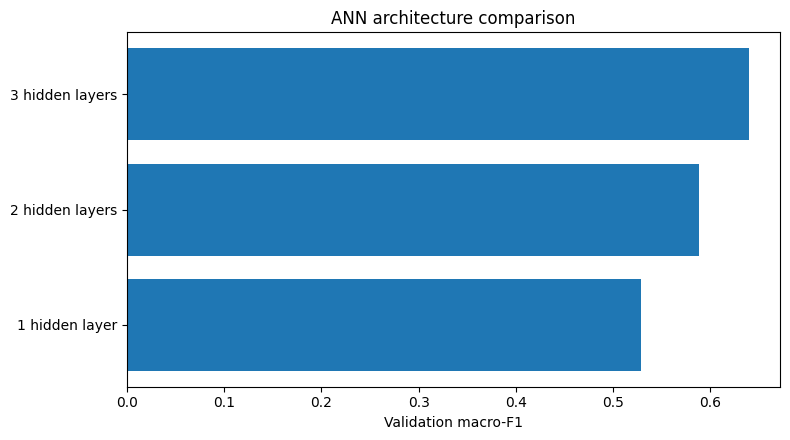

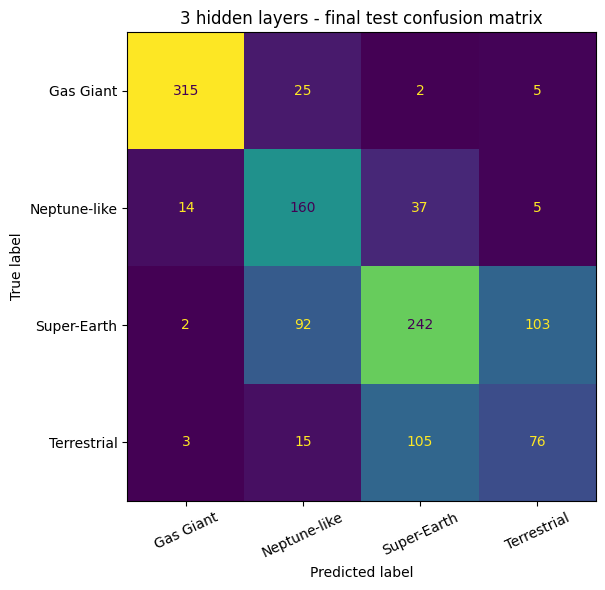

In [3]:
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
print('Class weights:', dict(zip(le.inverse_transform(classes), class_weights.round(3))))


def train_with_early_stopping(hidden_dims, dropout=0.2, lr=1e-3, weight_decay=1e-4, max_epochs=40, patience=6):
    torch.manual_seed(SEED)
    model = MLP(len(features), hidden_dims, len(le.classes_), dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)

    best_state = None
    best_val_loss = np.inf
    wait = 0
    hist = []

    for epoch in range(max_epochs):
        model.train()
        total_loss = 0.0
        seen = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
            seen += len(xb)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, torch.tensor(y_val, dtype=torch.long)).item()
        train_m = multiclass_metrics(model, X_train_t, y_train)
        val_m = multiclass_metrics(model, X_val_t, y_val)
        hist.append({
            'epoch': epoch + 1,
            'train_loss': total_loss / seen,
            'val_loss': val_loss,
            'train_accuracy': train_m['accuracy'],
            'validation_accuracy': val_m['accuracy'],
            'validation_macro_f1': val_m['macro_f1'],
        })

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

configs = [
    {'name': '1 hidden layer', 'hidden_dims': [32]},
    {'name': '2 hidden layers', 'hidden_dims': [64, 32]},
    {'name': '3 hidden layers', 'hidden_dims': [128, 64, 32]},
]

architecture_rows = []
trained = {}
for cfg in configs:
    model, hist = train_with_early_stopping(cfg['hidden_dims'])
    val_m = multiclass_metrics(model, X_val_t, y_val)
    architecture_rows.append({
        'architecture': cfg['name'],
        'epochs_run': len(hist),
        'validation_accuracy': val_m['accuracy'],
        'validation_macro_f1': val_m['macro_f1'],
    })
    trained[cfg['name']] = (model, hist)

architecture_df = pd.DataFrame(architecture_rows).sort_values('validation_macro_f1', ascending=False)
display(architecture_df.round(3))

selected_name = architecture_df.iloc[0]['architecture']
selected_model = trained[selected_name][0]
print('Selected architecture:', selected_name)

# Final test evaluation happens only now.
test_m = multiclass_metrics(selected_model, X_test_t, y_test)
print('Final ANN test accuracy:', round(test_m['accuracy'], 3))
print('Final ANN test macro-F1:', round(test_m['macro_f1'], 3))
print(classification_report(y_test, test_m['pred'], target_names=le.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = architecture_df.sort_values('validation_macro_f1')
ax.barh(plot_df['architecture'], plot_df['validation_macro_f1'])
ax.set_xlabel('Validation macro-F1')
ax.set_title('ANN architecture comparison')
fig.tight_layout()
fig.savefig(FIG_DIR / 'ann_architecture_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

cm_test = confusion_matrix(y_test, test_m['pred'])
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_test, display_labels=le.classes_).plot(ax=ax, values_format='d', colorbar=False, xticks_rotation=25)
ax.set_title(f'{selected_name} - final test confusion matrix')
fig.tight_layout()
fig.savefig(FIG_DIR / 'ann_final_confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Data-side analysis: focus on the most confused pair

The binary task is built from the pair identified **automatically on the multiclass validation confusion matrix**, avoiding the mismatch between comments, code, and report conclusions.

Hyperparameters for the binary ANN are selected using validation ROC-AUC. The binary test set is evaluated once at the end.

Binary task: Super-Earth vs Terrestrial


,hidden_dim,learning_rate,validation_roc_auc
4,32,0.001,0.663
0,8,0.001,0.646
2,16,0.001,0.641
3,16,0.000,0.622
5,32,0.000,0.613
1,8,0.000,0.586


Selected binary configuration: (32, 0.001)
accuracy     0.610
precision    0.420
recall       0.658
f1           0.513
roc_auc      0.674
dtype: float64


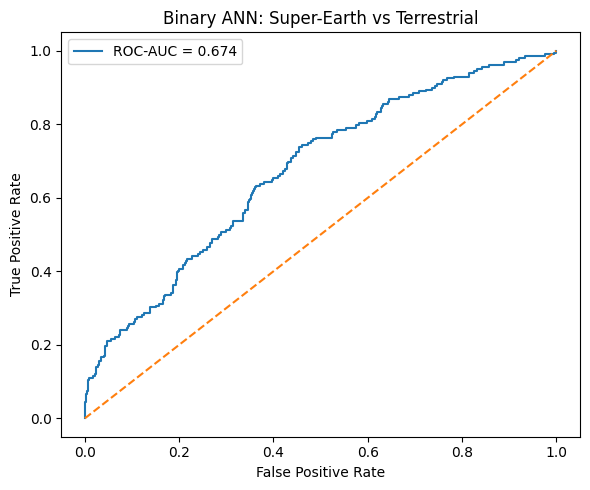

In [4]:
print('Binary task:', confused_pair[0], 'vs', confused_pair[1])

binary_df = df_clean[df_clean['planet_class'].isin(confused_pair)].copy()
binary_df['binary_label'] = (binary_df['planet_class'] == confused_pair[1]).astype(int)

Xb = binary_df[features].to_numpy(dtype=np.float32)
yb = binary_df['binary_label'].to_numpy()

Xb_train_full, Xb_test, yb_train_full, yb_test = train_test_split(
    Xb, yb, test_size=0.20, random_state=SEED, stratify=yb
)
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    Xb_train_full, yb_train_full, test_size=0.20, random_state=SEED, stratify=yb_train_full
)

b_scaler = StandardScaler()
Xb_train = b_scaler.fit_transform(Xb_train).astype(np.float32)
Xb_val = b_scaler.transform(Xb_val).astype(np.float32)
Xb_test = b_scaler.transform(Xb_test).astype(np.float32)

Xb_val_t = torch.tensor(Xb_val, dtype=torch.float32)
Xb_test_t = torch.tensor(Xb_test, dtype=torch.float32)

class BinaryANN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_binary(hidden_dim, lr, epochs=20):
    torch.manual_seed(SEED)
    model = BinaryANN(len(features), hidden_dim)
    n_pos = max(int((yb_train == 1).sum()), 1)
    n_neg = int((yb_train == 0).sum())
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    ds = TensorDataset(
        torch.tensor(Xb_train, dtype=torch.float32),
        torch.tensor(yb_train.reshape(-1, 1), dtype=torch.float32),
    )
    loader = DataLoader(ds, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(SEED))

    for _ in range(epochs):
        model.train()
        for xb_batch, yb_batch in loader:
            optimizer.zero_grad()
            logits = model(xb_batch)
            loss = criterion(logits, yb_batch)
            loss.backward()
            optimizer.step()
    return model

binary_rows = []
binary_models = {}
for hidden_dim in [8, 16, 32]:
    for lr in [1e-3, 5e-4]:
        model = train_binary(hidden_dim, lr)
        model.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(model(Xb_val_t)).squeeze(1).numpy()
        auc = roc_auc_score(yb_val, val_probs)
        binary_rows.append({'hidden_dim': hidden_dim, 'learning_rate': lr, 'validation_roc_auc': auc})
        binary_models[(hidden_dim, lr)] = model

binary_results = pd.DataFrame(binary_rows).sort_values('validation_roc_auc', ascending=False)
display(binary_results.round(3))

best_binary = binary_results.iloc[0]
key = (int(best_binary['hidden_dim']), float(best_binary['learning_rate']))
binary_model = binary_models[key]
print('Selected binary configuration:', key)

binary_model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(binary_model(Xb_test_t)).squeeze(1).numpy()
test_pred = (test_probs >= 0.5).astype(int)

binary_metrics = {
    'accuracy': accuracy_score(yb_test, test_pred),
    'precision': precision_score(yb_test, test_pred, zero_division=0),
    'recall': recall_score(yb_test, test_pred, zero_division=0),
    'f1': f1_score(yb_test, test_pred, zero_division=0),
    'roc_auc': roc_auc_score(yb_test, test_probs),
}
print(pd.Series(binary_metrics).round(3))

fpr, tpr, _ = roc_curve(yb_test, test_probs)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"ROC-AUC = {binary_metrics['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Binary ANN: {confused_pair[0]} vs {confused_pair[1]}')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'binary_ann_roc.png', dpi=160, bbox_inches='tight')
plt.show()

## Takeaways

- A separate validation set prevents early stopping and architecture selection from leaking information from the final test set.
- Class weighting, dropout, and early stopping are evaluated as model-side remedies for class confusion.
- The most-confused class pair is derived from the validation confusion matrix rather than hard-coded inconsistently.
- The focused binary experiment uses validation ROC-AUC for tuning and reports the test result only after selection.